### Análisis de incosistencias/patrones en los datos procesados

In [87]:
import pandas as pd
import plotly.express as px


In [88]:
df_original = pd.read_csv("../../data/eventos_espera_semana_hp.csv")
df_original.head()

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue
0,39bdae,2024-12-07 10:01:23.317,2024-12-07 10:01:35.915,2024-12-07 10:02:46.296,82.979,Medium 2 (between 34000 kg to 136000 kg),-3.561209,40.499423,-3.560089,40.499588,Y1,False,18L/36R,2024-12-07,10
1,4d24f1,2024-12-01 16:33:52.843,2024-12-01 16:34:13.202,2024-12-01 16:35:43.103,110.260,Medium 2 (between 34000 kg to 136000 kg),-3.576221,40.491579,-3.575317,40.492092,Z2,False,18R/36L,2024-12-01,16
2,71c082,2024-12-07 20:53:30.784,2024-12-07 20:53:51.610,2024-12-07 20:55:13.148,102.364,Heavy (larger than 136000 kg),-3.576253,40.491532,-3.575378,40.492081,Z2,False,18R/36L,2024-12-07,20
3,06a140,2024-12-01 18:26:29.008,2024-12-01 18:26:44.164,2024-12-01 18:27:29.141,60.133,Heavy (larger than 136000 kg),-3.561240,40.499423,-3.560074,40.499554,Y1,False,18L/36R,2024-12-01,18
4,06a140,2024-12-02 16:23:27.259,2024-12-02 16:23:41.536,2024-12-02 16:24:43.186,75.927,Heavy (larger than 136000 kg),-3.561234,40.499428,-3.560059,40.499599,Y1,False,18L/36R,2024-12-02,16


In [89]:
df_original.columns

Index(['ICAO', 'llegada_punto', 'salida_punto', 'despegue', 'tiempo_espera',
       'aircraft_type', 'llegada_lon', 'llegada_lat', 'salida_lon',
       'salida_lat', 'holding_point', 'parado', 'runway', 'fecha_despegue',
       'hora_despegue'],
      dtype='object')

In [90]:
print('Entre que fechas son los despegues')
print(df_original.despegue.min(), " -- ", df_original.despegue.max())

Entre que fechas son los despegues
2024-12-01 00:39:48.750  --  2024-12-07 23:57:09.599


In [91]:
counts = df_original.parado.value_counts().reset_index()
counts.columns = ['parado', 'count']
fig = px.bar(counts, x='parado', y='count', text='count',width=500, height=500)
fig.show()

In [92]:
px.histogram(df_original, 'tiempo_espera', title='Distribución segundos de espera')

In [93]:
px.histogram(df_original[df_original.tiempo_espera < 20 * 60], 'tiempo_espera', title='Distribución segundos de espera (menores a 20 mins)')

In [94]:
px.histogram(df_original[df_original.tiempo_espera < 10 * 60], 'tiempo_espera', title='Distribución segundos de espera (menores a 10 mins)')

Nos quedamos con los últimos datos

In [97]:
df = df_original.copy()
df = df[df.tiempo_espera < 10 * 60]
print(df_original.shape[0], "->", df.shape[0])

4005 -> 3891


### Analisis de NA's

In [98]:
df.isna().sum()

ICAO               0
llegada_punto      0
salida_punto       7
despegue           0
tiempo_espera      0
aircraft_type     13
llegada_lon        0
llegada_lat        0
salida_lon         7
salida_lat         7
holding_point      0
parado             0
runway             2
fecha_despegue     0
hora_despegue      0
dtype: int64

In [99]:
df[df['aircraft_type'].isna()].head(3)

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue
1122,34530e,2024-12-06 10:37:39.491,2024-12-06 10:38:36.060,2024-12-06 10:39:40.581,121.090,NaN,-3.573471,40.491829,-3.573787,40.491823,Z3,True,18R/36L,2024-12-06,10
1449,3c664b,2024-12-03 13:15:05.095,2024-12-03 13:15:22.467,2024-12-03 13:16:35.052,89.957,NaN,-3.561203,40.499416,-3.560101,40.499586,Y1,False,18L/36R,2024-12-03,13
1450,3c664b,2024-12-06 07:36:45.713,2024-12-06 07:36:55.835,2024-12-06 07:38:01.675,75.962,NaN,-3.561218,40.499416,-3.560089,40.499577,Y1,False,18L/36R,2024-12-06,7


#### 2 despegues en menos de 5 minutos

In [100]:
df[df['ICAO'] == '34530e'].iloc[9:11]

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue
1121,34530e,2024-12-06 10:37:17.504,2024-12-06 10:37:37.380,2024-12-06 10:37:37.380,19.876,Medium 2 (between 34000 kg to 136000 kg),-3.572861,40.491840,-3.573471,40.491829,Z3,True,NaN,2024-12-06,10
1122,34530e,2024-12-06 10:37:39.491,2024-12-06 10:38:36.060,2024-12-06 10:39:40.581,121.090,NaN,-3.573471,40.491829,-3.573787,40.491823,Z3,True,18R/36L,2024-12-06,10


In [101]:
df[df['runway'].isna()]

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue
1121,34530e,2024-12-06 10:37:17.504,2024-12-06 10:37:37.380,2024-12-06 10:37:37.380,19.876,Medium 2 (between 34000 kg to 136000 kg),-3.572861,40.491840,-3.573471,40.491829,Z3,True,NaN,2024-12-06,10
2796,34444b,2024-12-01 08:30:54.936,2024-12-01 08:31:11.578,2024-12-01 08:33:12.261,137.325,Medium 2 (between 34000 kg to 136000 kg),-3.537879,40.472422,-3.537098,40.471643,KA6,False,NaN,2024-12-01,8


In [102]:
df[df['salida_punto'].isna()].head(2)

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue
623,344417,2024-12-02 11:02:03.411,NaN,2024-12-02 11:08:33.045,389.634,Medium 2 (between 34000 kg to 136000 kg),-3.574707,40.486782,NaN,NaN,LD,True,14R/32L,2024-12-02,11
646,344455,2024-12-02 11:31:15.570,NaN,2024-12-02 11:38:51.108,455.538,Medium 2 (between 34000 kg to 136000 kg),-3.574753,40.486794,NaN,NaN,LD,False,14R/32L,2024-12-02,11


Hay un segundo punto, despues del punto que no tiene salida

In [106]:
df[df['ICAO'] == '344417'].iloc[3:5]

,ICAO,llegada_punto,salida_punto,despegue,tiempo_espera,aircraft_type,llegada_lon,llegada_lat,salida_lon,salida_lat,holding_point,parado,runway,fecha_despegue,hora_despegue
623,344417,2024-12-02 11:02:03.411,NaN,2024-12-02 11:08:33.045,389.634,Medium 2 (between 34000 kg to 136000 kg),-3.574707,40.486782,NaN,NaN,LD,True,14R/32L,2024-12-02,11
624,344417,2024-12-02 11:07:00.362,2024-12-02 11:07:11.477,2024-12-02 11:08:33.045,92.683,Medium 2 (between 34000 kg to 136000 kg),-3.575226,40.486496,-3.575531,40.486256,LC,False,14R/32L,2024-12-02,11


### Eliminamos filas con algún NA

In [131]:
df = df.dropna()

Vamos a ver el numero de despegues por avion

In [147]:
icao_counts = df.drop_duplicates(subset=['ICAO', 'despegue']) # para no contar el mismo despegue 2 veces si pasa por 2 puntos
icao_counts = icao_counts.groupby(["ICAO", "aircraft_type"])["despegue"].count()
print("MAX", icao_counts.max())
print("MEDIA", icao_counts.mean())
print("MEDIANA", icao_counts.median())
fig = px.histogram(icao_counts.reset_index(), 'despegue', title='Distribución numero de despegues por avion', labels={'despegue': 'total numero de despegue'})
fig.show()

MAX 24
MEDIA 3.3385146804835926
MEDIANA 1.0


In [148]:
fig = px.histogram(icao_counts.reset_index(), 'despegue', color="aircraft_type", title='Distribución numero de despegues por avion', labels={'despegue': 'total numero de despegue'})
fig.show()

In [157]:
hp_count = df.groupby(["ICAO", "despegue"])["holding_point"].count().sort_values(ascending=False)

In [158]:
hp_count[hp_count > 1]

ICAO    despegue               
4b027d  2024-12-05 20:54:14.920    3
4951d3  2024-12-02 09:36:53.190    2
Name: holding_point, dtype: int64

#### Solo hay 2 casos donde los aviones pasan por mas de 1 punto de espera al despegar

In [126]:
import geopandas as gpd

gdf = gpd.read_file('../../data/geojson/holding_points.geojson')
taxiways = gpd.read_file("../../data/geojson/taxiways.geojson")
runways = gpd.read_file("../../data/geojson/runways.geojson")
gdf.head(1)

,OBJECTID,LASTMOD_DATE,LAT_TXT,LONG_TXT,GFID,LATLONG_RESOLUTION,LATLONG_ACCURACY,LASTMOD_AMDT,DESIGNATOR,STOPBAR,PARENT_ADHP,REMARKS_TXT,geometry
0,1190,1689239365000,"402926,3514N","0033423,1352W",87F4653B-2759-449F-8558-223A85EE69EA,None,None,AIRAC - 10/23,Z1,1.0,C46939D7-07D9-4BA7-9D4C-AF3E1B30DCD0,Con iluminación LED. // LED ligthing.,POINT (-3.57309 40.49065)


/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_71875/2696595465.py:13: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_71875/2696595465.py:16: UserWarning:

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.


/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_71875/2696595465.py:31: UserWarning:

Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler



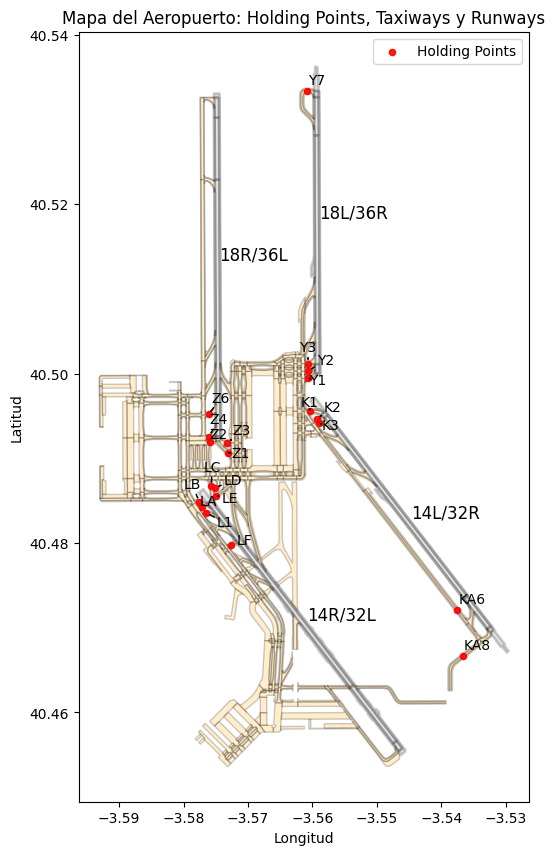

In [145]:
import matplotlib.pyplot as plt

from adjustText import adjust_text # basicamente ayuda a que el texto no solape

fig, ax = plt.subplots(figsize=(10, 10))

texts = []
for x, y, label in zip(gdf.geometry.x, gdf.geometry.y, gdf['DESIGNATOR']):
    texts.append(ax.text(x, y, label, fontsize=10, ha='left', va='bottom'))

# convertimos en una sola pieza (poligono)
runways_grouped = runways.dissolve(by='RWY', as_index=False)
runways_grouped['centroid'] = runways_grouped.geometry.centroid
runways_grouped.head()

for x, y, label in zip(runways_grouped.centroid.x, runways_grouped.centroid.y, runways_grouped['RWY']):
    texts.append(ax.text(x, y, label, fontsize=12, ha='left', va='bottom'))

# Plot layers
runways.plot(ax=ax, color="gray", edgecolor="black", alpha=0.2, linewidth=2, label="Runways")
taxiways.plot(ax=ax, color="orange", edgecolor="black", alpha=0.2, label="Taxiways")
gdf.plot(ax=ax, color="red", markersize=20, alpha=0.9, label="Holding Points")

# Adjust text to avoid overlaps
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='black'))

# Añadir título y leyenda
plt.title("Mapa del Aeropuerto: Holding Points, Taxiways y Runways")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.legend()

# Mostrar el mapa
plt.show();

Vemos la distribución de las pistas

In [66]:

counts = df['runway'].value_counts().reset_index()
counts.columns = ['runway', 'count']
fig = px.bar(counts, x='runway', y='count', text='count',width=500, height=500)
fig.show()

In [ ]:
import plotly.express as px

value_counts = df['holding_point'].value_counts().reset_index()
value_counts.columns = ['holding_point', 'count']

fig = px.bar(value_counts, x='holding_point', y='count', title='Despegues por puntos de espera', text='count')

fig.update_layout(template='plotly_white')

fig.show()


In [ ]:
# Extract latitude and longitude from geometry
gdf['lat'] = gdf.geometry.y
gdf['lon'] = gdf.geometry.x

# Value counts
value_counts = df['holding_point'].value_counts().reset_index()
value_counts.columns = ['holding_point', 'count']

# Merge counts into GeoDataFrame
gdf_merged = gdf.merge(value_counts, left_on='DESIGNATOR', right_on='holding_point', how='left')
gdf_merged['count'] = gdf_merged['count'].fillna(0)

# Plot the holding points on a map
fig = px.scatter_mapbox(
    gdf_merged,
    lat='lat',
    lon='lon',
    text='DESIGNATOR',
    size='count',
    size_max=20,
    zoom=11.4
)

fig.update_layout(
    mapbox_style="carto-positron",
    margin={"r": 0, "t": 0, "l": 0, "b": 0}
)

fig.show();

/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_71875/2990192652.py:14: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



In [67]:
import pandas as pd
import plotly.express as px

counts_fecha = df[['despegue', 'runway']].copy()
counts_fecha['despegue'] = pd.to_datetime(counts_fecha['despegue']).dt.floor('H') # redondea a la hora (para eliminar minutos y segundos)

counts_fecha = counts_fecha.value_counts().reset_index()

# en este creamos una rejilla, para todas las fechas por horas y todos los runways
# para que en el grafico salga la línea en el 0 si no ha habido despegues a esa hora
all_hours = pd.date_range(start=counts_fecha['despegue'].min(), end=counts_fecha['despegue'].max(), freq='H')
all_runways = counts_fecha['runway'].unique()

full_index = pd.MultiIndex.from_product([all_hours, all_runways], names=['despegue', 'runway'])
counts_full = counts_fecha.set_index(['despegue', 'runway']).reindex(full_index, fill_value=0).reset_index()


fig = px.line(counts_full, x='despegue', y='count', color='runway',
              title='Despegues por horas y pista')
fig.show()

/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_71875/713076718.py:5: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_71875/713076718.py:11: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



In [159]:
import pandas as pd
import plotly.express as px

counts_fecha = df[['despegue', 'holding_point']].copy()
counts_fecha['despegue'] = pd.to_datetime(counts_fecha['despegue']).dt.floor('H') # redondea a la hora (para eliminar minutos y segundos)

counts_fecha = counts_fecha.value_counts().reset_index()

# en este creamos una rejilla, para todas las fechas por horas y todos los runways
# para que en el grafico salga la línea en el 0 si no ha habido despegues a esa hora
all_hours = pd.date_range(start=counts_fecha['despegue'].min(), end=counts_fecha['despegue'].max(), freq='H')
all_runways = counts_fecha['holding_point'].unique()

full_index = pd.MultiIndex.from_product([all_hours, all_runways], names=['despegue', 'holding_point'])
counts_full = counts_fecha.set_index(['despegue', 'holding_point']).reindex(full_index, fill_value=0).reset_index()


fig = px.line(counts_full, x='despegue', y='count', color='holding_point',
              title='Despegues por horas y holding point')
fig.show()

/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_71875/419709331.py:5: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

/var/folders/d9/w858q_3s5xj1lvw2flnmb_jr0000gn/T/ipykernel_71875/419709331.py:11: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.



In [68]:
pivot_df = df.pivot_table(index='holding_point', columns='runway', values='despegue', aggfunc='count').T

fig = px.imshow(pivot_df, title='Despegues por pista y punto de espera')
fig.show()
